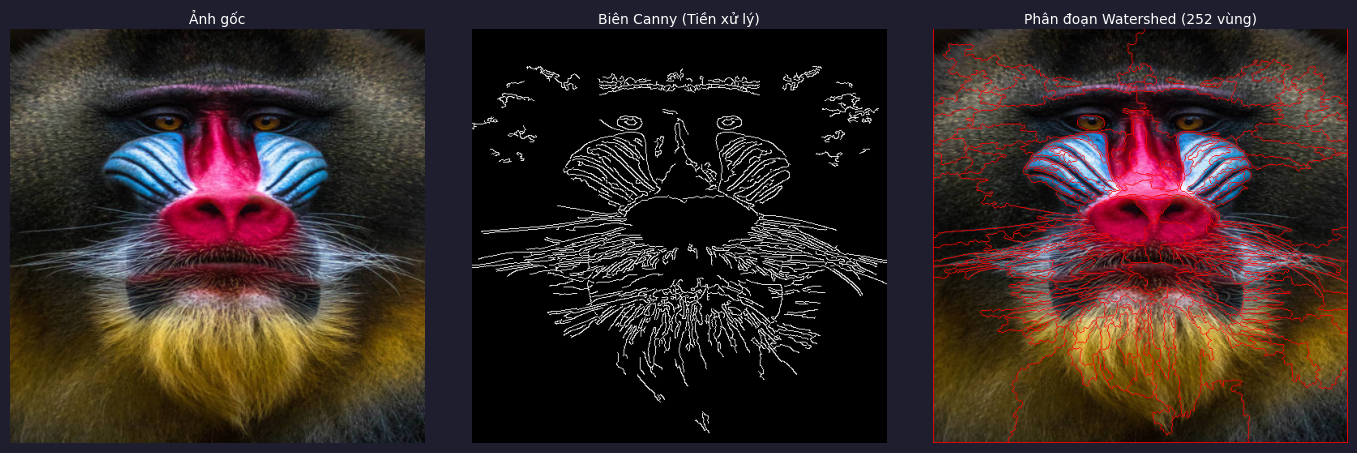

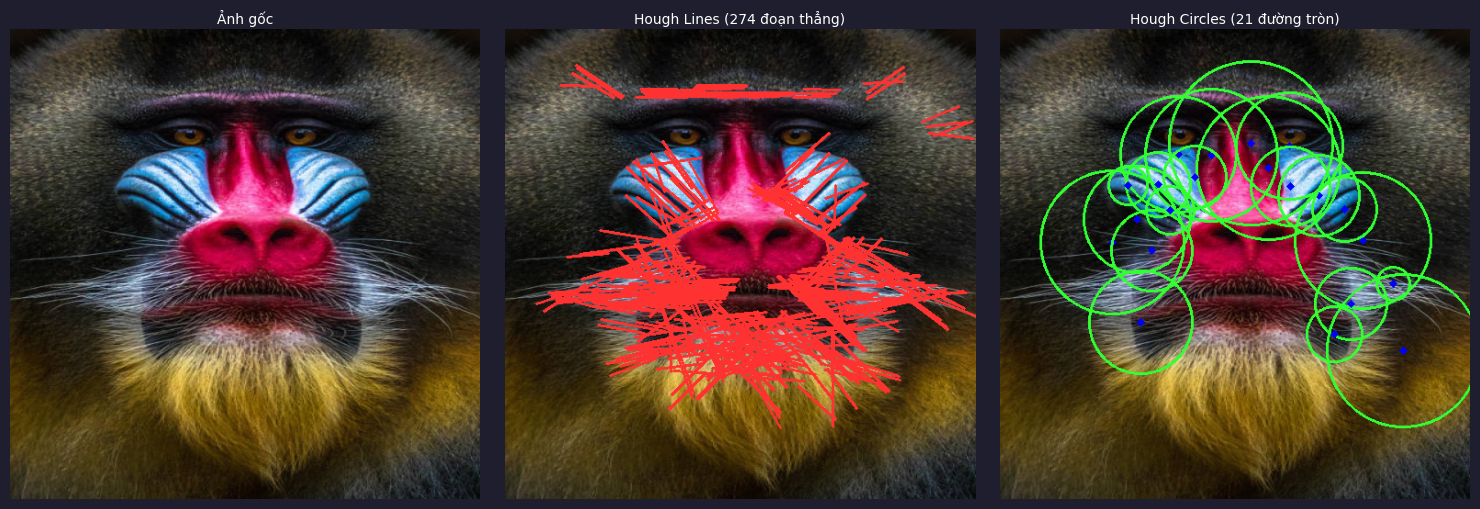

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("../input/lab_image.jpg")
if img_bgr is None:
    raise FileNotFoundError("Không tìm thấy ảnh tại ../input/lab_image.jpg")
img_bgr = cv2.resize(img_bgr, (512, 512), interpolation=cv2.INTER_AREA)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

def show(ax, img, title):
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(title, pad=4, fontsize=10, color="white")
    ax.axis("off")

fig_bg = "#1e1e2e"

# (WATERSHED ALGORITHM)

edge = cv2.Canny(cv2.GaussianBlur(img_gray, (5, 5), 0), 50, 150)

contours, _ = cv2.findContours(edge.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
markers = np.zeros(img_gray.shape, dtype=np.int32)
for i, c in enumerate(contours):
    cv2.drawContours(markers, [c], 0, i + 1, -1)

img_ws = img_bgr.copy()
cv2.watershed(img_ws, markers)
img_ws[markers == -1] = [0, 0, 255] # Biên màu đỏ
img_ws_rgb = cv2.cvtColor(img_ws, cv2.COLOR_BGR2RGB)

fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4.5), facecolor=fig_bg)
show(axes1[0], img_rgb, "Ảnh gốc")
show(axes1[1], edge, "Biên Canny (Tiền xử lý)")
show(axes1[2], img_ws_rgb, f"Phân đoạn Watershed ({len(contours)} vùng)")
plt.tight_layout()
plt.show()

# HOUGH LINES + CIRCLES

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), facecolor=fig_bg)

# Hough Lines 
edg_h = cv2.Canny(cv2.GaussianBlur(img_gray, (3, 3), 0), 50, 200)
lines = cv2.HoughLinesP(edg_h, 1, np.pi / 180, threshold=60, minLineLength=40, maxLineGap=10)

img_lines = img_rgb.copy()
n_lines = 0
if lines is not None:
    n_lines = len(lines)
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines, (x1, y1), (x2, y2), (255, 50, 50), 2) 

# Hough Circles-
blr_c = cv2.GaussianBlur(img_gray, (9, 9), 2)
circles = cv2.HoughCircles(blr_c, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                           param1=100, param2=30, minRadius=10, maxRadius=100)

img_circles = img_rgb.copy()
n_circles = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    n_circles = len(circles[0])
    for c in circles[0]:
        # Vẽ viền đường tròn
        cv2.circle(img_circles, (c[0], c[1]), c[2], (50, 255, 50), 2) 
        # Vẽ tâm đường tròn
        cv2.circle(img_circles, (c[0], c[1]), 2, (0, 0, 255), 3)      

show(axes2[0], img_rgb, "Ảnh gốc")
show(axes2[1], img_lines, f"Hough Lines ({n_lines} đoạn thẳng)")
show(axes2[2], img_circles, f"Hough Circles ({n_circles} đường tròn)")

plt.tight_layout()
plt.show()